# The Bonded Foil Strain Gage
### *Modern Strain Gage Technology* — Companion Notebook

**Companion notebook to Chapter 23 — The Bonded Foil Strain Gage.**

A gage is calibrated in a clean uniaxial pull, but it almost never *lives* there — and the small amount it listens sideways, to strain across its axis, turns into a systematic error the moment the real stress field goes biaxial.

The gage factor GF is fixed at the factory by applying a *known uniaxial strain* to a calibration beam and measuring the resistance change. Real test articles, though, are rarely in a uniaxial stress state — biaxial loads, bending combined with tension, and complex geometry all produce fields where the strain *across* the grid is nonzero. Because the grid responds slightly to that transverse strain as well as to axial strain, the stated GF carries a systematic error whenever the biaxiality ratio $K = \varepsilon_t/\varepsilon_a$ departs from the calibration condition.

This *transverse sensitivity* error is usually small — the *transverse sensitivity factor* $K_t$ runs from about 0.3% to 3% for foil gages, as Chapter 23 notes — but the resulting strain error can still reach several percent of the reading in strongly biaxial fields. The figure below plots the error against the biaxiality ratio $K$ for a representative gage with $K_t = 1\%$, making clear that the error vanishes only at the calibration condition ($K = -\nu_0 \approx -0.285$) and grows as $K$ moves away from it.

**This notebook demonstrates:**
1. Transverse sensitivity error (%) as a function of the biaxiality ratio $K = \varepsilon_t/\varepsilon_a$, for a gage with $K_t = 1\%$.


In [1]:
# Colab setup — installs the dependencies used below (harmless no-op if already present):
# !pip install numpy matplotlib

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Plot styling shared by every figure in this notebook.
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Output location for the figure that appears in Chapter 23.
# Do NOT change this path — the book \includegraphics this exact file.
OUT_DIR = Path("../src/media/ch23")
OUT_DIR.mkdir(parents=True, exist_ok=True)


---
## 1 — Transverse Sensitivity Error vs. Biaxiality Ratio

The *transverse sensitivity factor* $K_t$ measures how much the gage responds to strain perpendicular to its primary axis. A perfectly axial gage would have $K_t = 0$; real foil gages fall between about 0.3% and 3% depending on grid geometry and end-loop design. Calibration fixes GF at the condition $K = -\nu_0$ — the Poisson contraction of a metal calibration beam under uniaxial stress, with $\nu_0 \approx 0.285$ — so the error is zero there by construction.

The grid actually responds to a weighted sum of both strain components, $\Delta R/R \propto \varepsilon_a + K_t\,\varepsilon_t$. Fixing GF under uniaxial calibration ($\varepsilon_t = -\nu_0\,\varepsilon_a$) and then reading a general field leaves the fractional error given by Micro-Measurements TN-509:

$$\text{error} \;=\; \frac{K_t\,(K + \nu_0)}{1 - \nu_0\,K_t}, \qquad K \equiv \frac{\varepsilon_t}{\varepsilon_a}.$$

In plain English: the error scales with the transverse sensitivity factor and with how far the biaxiality ratio sits from the calibration value $-\nu_0$; it vanishes exactly at $K = -\nu_0$ and grows on either side.

Moving away from $K = -\nu_0$ introduces error in both directions. At $K = 0$ (uniaxial stress on the test article) the error is small but nonzero — for $K_t = 1\%$ it is about $+0.29\%$. At $K = +1$ (equibiaxial stress, common near holes and fillets) it reaches $\sim\!1.3\%$. The correction is straightforward when $K_t$ is printed on the gage certificate and the biaxiality ratio is measured with a rosette — but it needs two readings, which is why low-$K_t$ gages are preferred for critical biaxial work.


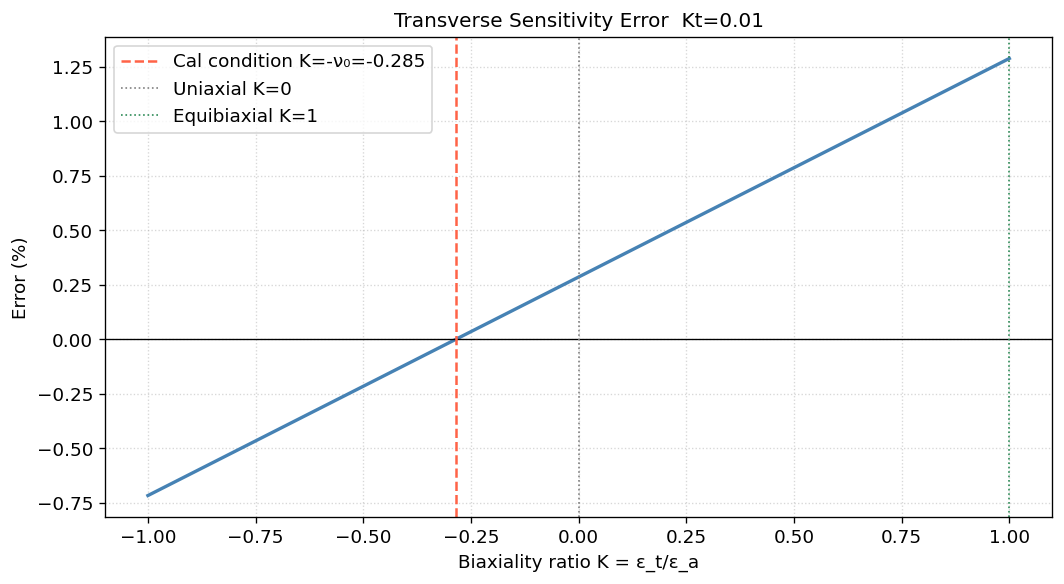

Uniaxial     K=+0.000  error=+0.2858%
Calibration  K=-0.285  error=+0.0000%
Equibiaxial  K=+1.000  error=+1.2887%


In [2]:
# Physical parameters (named, not magic numbers).
KT = 0.01     # transverse sensitivity factor of the gage (1%), a representative foil value
NU0 = 0.285   # Poisson's ratio of the calibration beam; sets the zero-error condition K = -NU0

# Sweep range for the biaxiality ratio K = eps_t / eps_a.
K_MIN, K_MAX, N_POINTS = -1.0, 1.0, 200


def transverse_sensitivity_error(K, Kt=KT, nu0=NU0):
    """Percent error in indicated axial strain from neglecting transverse sensitivity.

    A gage whose factor GF is fixed under uniaxial calibration (biaxiality ratio
    K = -nu0) and then used to read a field of biaxiality ratio K = eps_t/eps_a
    carries the error given by Micro-Measurements TN-509:

        error(%) = 100 * Kt * (K + nu0) / (1 - nu0 * Kt)

    The error is exactly zero at the calibration condition K = -nu0 and grows as
    K departs from it.

    Parameters
    ----------
    K : float or numpy.ndarray
        Biaxiality ratio eps_t / eps_a of the measured strain field.
    Kt : float, optional
        Transverse sensitivity factor of the gage.
    nu0 : float, optional
        Poisson's ratio of the calibration beam.

    Returns
    -------
    float or numpy.ndarray
        Percentage error in the indicated axial strain.
    """
    return 100.0 * Kt * (K + nu0) / (1.0 - nu0 * Kt)


K_biax = np.linspace(K_MIN, K_MAX, N_POINTS)
error_pct = transverse_sensitivity_error(K_biax)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_biax, error_pct, 'steelblue', lw=2)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(-NU0, color='tomato', lw=1.5, linestyle='--', label=f'Cal condition K=-ν₀={-NU0}')
ax.axvline(0, color='gray', lw=1, linestyle=':', label='Uniaxial K=0')
ax.axvline(1, color='seagreen', lw=1, linestyle=':', label='Equibiaxial K=1')
ax.set_xlabel('Biaxiality ratio K = ε_t/ε_a'); ax.set_ylabel('Error (%)')
ax.set_title(f'Transverse Sensitivity Error  Kt={KT}'); ax.legend(); ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout(); plt.savefig(OUT_DIR / 'fig23_nb1_transverse_sensitivity_error.png', bbox_inches='tight', dpi=150)
plt.show()

# Representative points, computed with the same function that draws the curve.
for K, lbl in [(0.0, "Uniaxial"), (-NU0, "Calibration"), (1.0, "Equibiaxial")]:
    print(f"{lbl:12s} K={K:+.3f}  error={transverse_sensitivity_error(K):+.4f}%")


---
## Where to take this next

The single curve above is a starting point. A few concrete extensions turn it into a working transverse-sensitivity tool:

1. **Sweep the gage quality, not just the load.** Draw a family of curves for $K_t = 0.3\%,\ 1\%,\ 3\%$ — the full range Chapter 23 quotes — on one set of axes. This shows how much of the biaxial error is set by the *gage you buy* versus the *field you measure*, and it bounds the worst case at $K = +1$ for each grade.
2. **Implement the two-gage TN-509 correction.** Given two overlaid readings (for example, the two grids of a tee rosette) and their $K_t$, solve the pair of equations for the *true* $\varepsilon_a$ and $\varepsilon_t$, then compare the corrected strain against the raw indicated strain. Quantify how many microstrain the rosette recovers at a given biaxiality ratio.
3. **Anchor the curve to real features.** Overlay annotated markers at the biaxiality ratios of common test articles — $K \approx 0$ for a uniaxial tensile coupon, $K \approx +1$ for the wall of a thin pressure vessel, $K \approx -\nu_0$ for the calibration beam itself — so the abstract axis maps onto the parts an engineer actually instruments.
